### **Image Classification using Random Forest **

Introduction

This assignment is designed to assess your understanding of image classification using machine learning techniques. You will build a model that can accurately classify images into different categories using Random Forest. The project will involve data preprocessing, model training, result interpretation, and a conceptual discussion on deploying the model.
###


In [3]:
### 1. Dataset Selection and Preprocessing:

In [4]:
# Import Libraries

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
#%matplotlib notebook
%matplotlib inline
from sklearn import svm, metrics, datasets
from sklearn.utils import Bunch
from sklearn.model_selection import GridSearchCV, train_test_split

from skimage.io import imread
from skimage.transform import resize
import skimage.io # Import the skimage module

In [5]:
# Loading the image files
import os

image_folder = "C:/GitHub/Colab-git-demo-tep/images"  # Path to the image folder
categories = os.listdir(image_folder)  # Get the list of categories

for category in categories:
  category_path = os.path.join(image_folder, category)
  for image_file in os.listdir(category_path):
    image_path = os.path.join(category_path, image_file)
    # Process the image file (e.g., read using OpenCV or Pillow)

### Load images in structured directory 

In [6]:
def load_image_files(container_path, dimension=(64, 64)):
    """
    Load image files with categories as subfolder names
    which performs like scikit-learn sample dataset

    Parameters
    ----------
    container_path : string or unicode
        Path to the main folder holding one subfolder per category
    dimension : tuple
        size to which image are adjusted to

    Returns
    -------
    Bunch
    """
    image_dir = Path(container_path)
    folders = [directory for directory in image_dir.iterdir() if directory.is_dir()]
    categories = [fo.name for fo in folders]

    descr = "A image classification dataset"
    images = []
    flat_data = []
    target = []
    for i, direc in enumerate(folders):
        for file in direc.iterdir():
            img = skimage.io.imread(file)
            img_resized = resize(img, dimension, anti_aliasing=True, mode='reflect')
            flat_data.append(img_resized.flatten())
            images.append(img_resized)
            target.append(i)
    flat_data = np.array(flat_data)
    target = np.array(target)
    images = np.array(images)

    return Bunch(data=flat_data,
                 target=target,
                 target_names=categories,
                 images=images,
                 DESCR=descr)

In [7]:
# Update the path to where your images are located
image_dataset = load_image_files("C:/GitHub/Colab-git-demo-tep/images/")

### 2. Model Training

### Split data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    image_dataset.data, image_dataset.target, test_size=0.3,random_state=109)

### Train data with parameter optimization

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Create Random Forest model
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Grid Search
clf = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train the model
clf.fit(X_train, y_train)

# Best parameters
print("Best parameters:", clf.best_params_)

# Best cross-validation score
print("Best CV accuracy:", clf.best_score_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV accuracy: 0.7498942917547569


In [18]:
### 3. Model Evaluation

### Predict

In [14]:
# Make predictions
y_pred = clf.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(y_test, y_pred))


Test Accuracy: 0.7311827956989247


### Report

In [15]:
# Print a detailed classification report (Precision, Recall, F1-Score)

print(metrics.classification_report(y_test, y_pred, target_names=image_dataset.target_names))

              precision    recall  f1-score   support

   dalmatian       0.68      0.59      0.63        22
 dollar_bill       0.71      0.71      0.71        17
       pizza       0.83      0.71      0.77        14
 soccer_ball       0.58      0.65      0.61        17
   sunflower       0.85      0.96      0.90        23

    accuracy                           0.73        93
   macro avg       0.73      0.72      0.72        93
weighted avg       0.73      0.73      0.73        93



In [27]:
###
###The Random Forest model achieved an overall accuracy of 73%. 
###The sunflower class performed best, while soccer_ball had lower F1-scores and precision.

###

In [20]:
# feature importances
# Get the best Random Forest model
best_rf = clf.best_estimator_

# Get feature importances
feature_importances = best_rf.feature_importances_

# Display feature importances
print(feature_importances)

[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 5.47415657e-05
 0.00000000e+00 0.00000000e+00]


In [24]:
### 4. Feature Importance Visualization

import pandas as pd
import numpy as np

# Get the best Random Forest model
best_rf = clf.best_estimator_

# Get feature importances
importance_df = pd.DataFrame({
    'Feature': range(X_train.shape[1]),
    'Importance': best_rf.feature_importances_
})

# Sort from most to least important
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display the top 10 features
importance_df.head(10)

,Feature,Importance
4292,4292,0.005488
4493,4493,0.003810
4922,4922,0.003726
4343,4343,0.003291
4298,4298,0.003060
3344,3344,0.003002
6992,6992,0.002838
3950,3950,0.002830
4340,4340,0.002818
4532,4532,0.002800


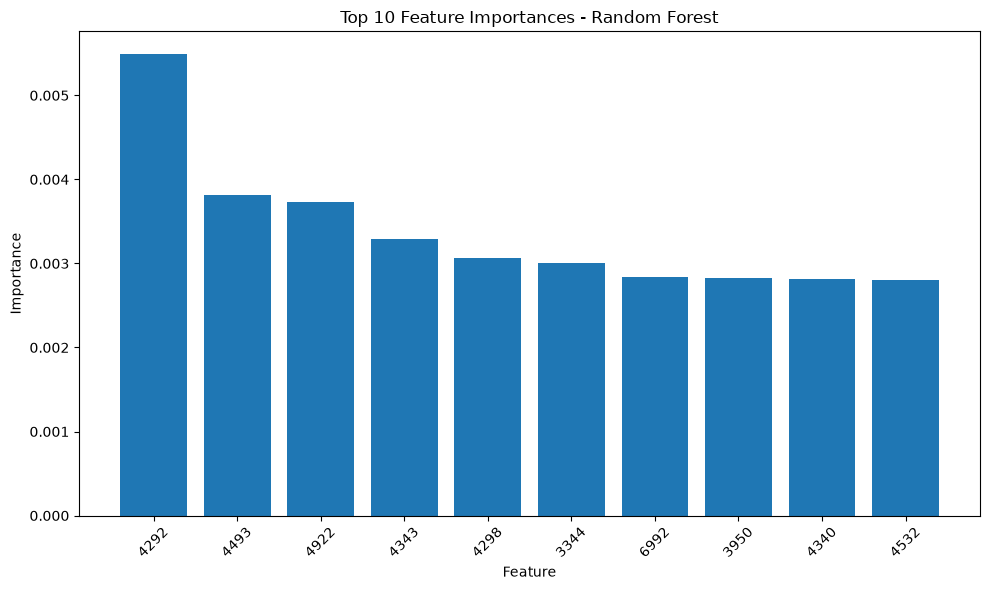

In [25]:
# Create a bar plot of feature importances using matplotlib.pyplot.
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_features['Feature'].astype(str),
    top_features['Importance']
)

plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
## 5. Prediction on New Images

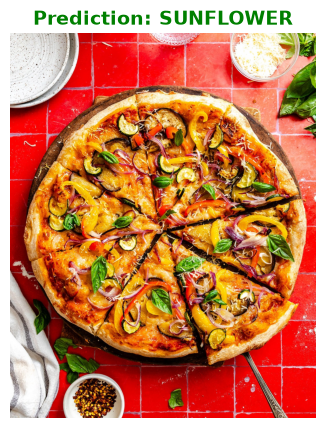

In [28]:
import matplotlib.pyplot as plt
import skimage.io
from skimage.transform import resize
import numpy as np

# 1. Define the path to your test image
# Make sure to replace this with your actual file name!
sample_image_path = "Pizza_test.jpg" 

try:
    # 2. Read and preprocess the single image
    img = skimage.io.imread(sample_image_path)
    
    # Resize to the exact dimension your model expects (64x64)
    # The training function uses anti_aliasing=True and mode='reflect'
    img_resized = resize(img, (64, 64), anti_aliasing=True, mode='reflect')
    
    # 3. Flatten the image to create a 1D vector of features
    # img_resized.flatten() returns 12,288 numbers
    # We wrap it in an extra array [ ... ] because the model expects a 2D batch of samples
    flattened_image = np.array([img_resized.flatten()])
    
    # 4. Use your trained GridSearch object (clf) to make the prediction
    predicted_index = clf.predict(flattened_image)[0]
    
    # 5. Map the numerical prediction index back to the human-readable text name
    # image_dataset.target_names holds ['dalmatian', 'dollar_bill', 'pizza', ...]
    predicted_category = image_dataset.target_names[predicted_index]
    
    # 6. Display the image and the model's prediction side-by-side
    plt.figure(figsize=(5, 5))
    plt.imshow(img)  # Displays the original un-resized image for clarity
    plt.title(f"Prediction: {predicted_category.upper()}", fontsize=14, color='green', fontweight='bold')
    plt.axis('off')
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find the file at '{sample_image_path}'. Please check your file name and path.")
except NameError:
    print("Error: Make sure your 'clf' model and 'image_dataset' variables are still loaded in memory.")

In [ ]:
'''
The model incorrectly classified this image as another class instead of pizza.
'''

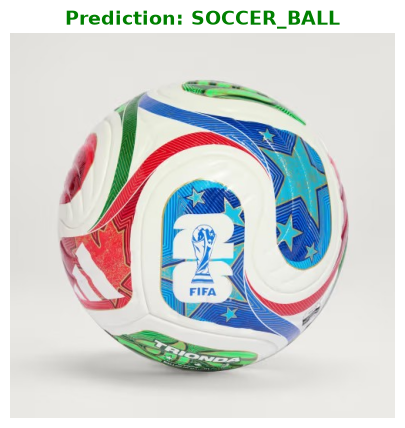

In [29]:
import matplotlib.pyplot as plt
import skimage.io
from skimage.transform import resize
import numpy as np

# 1. Define the path to your test image
# Make sure to replace this with your actual file name!
sample_image_path = "soccer_test21.jpg" 

try:
    # 2. Read and preprocess the single image
    img = skimage.io.imread(sample_image_path)
    
    # Resize to the exact dimension your model expects (64x64)
    # The training function uses anti_aliasing=True and mode='reflect'
    img_resized = resize(img, (64, 64), anti_aliasing=True, mode='reflect')
    
    # 3. Flatten the image to create a 1D vector of features
    # img_resized.flatten() returns 12,288 numbers
    # We wrap it in an extra array [ ... ] because the model expects a 2D batch of samples
    flattened_image = np.array([img_resized.flatten()])
    
    # 4. Use your trained GridSearch object (clf) to make the prediction
    predicted_index = clf.predict(flattened_image)[0]
    
    # 5. Map the numerical prediction index back to the human-readable text name
    # image_dataset.target_names holds ['dalmatian', 'dollar_bill', 'pizza', ...]
    predicted_category = image_dataset.target_names[predicted_index]
    
    # 6. Display the image and the model's prediction side-by-side
    plt.figure(figsize=(5, 5))
    plt.imshow(img)  # Displays the original un-resized image for clarity
    plt.title(f"Prediction: {predicted_category.upper()}", fontsize=14, color='green', fontweight='bold')
    plt.axis('off')
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find the file at '{sample_image_path}'. Please check your file name and path.")
except NameError:
    print("Error: Make sure your 'clf' model and 'image_dataset' variables are still loaded in memory.")

In [ ]:
'''
The model correctly classified this image as a soccer ball.
'''

In [ ]:
###  Bonus: Comparing with SVM:

In [ ]:
### Compare the results of Random Forest and SVM models.

In [ ]:
'''
The SVM model performed slightly better with higher accuracy of 76%, while the Random Forest model has 73%. 
SVM also had higher precision and recall for some classes, such as dollar_bill (0.87 precision, 0.76 recall) and pizza (0.85 precision, 0.79 recall). 
SVM correctly classified the pizza example, while Random Forest correctly classified the soccer ball example.
'''